# Optimization Comparison

Choosing the right classical optimizer is critical for Variational Algorithms, especially when running on real, noisy quantum hardware. 

This notebook compares:
1. **COBYLA**: A gradient-free optimizer good for statevector (noiseless) simulations.
2. **SPSA** (Simultaneous Perturbation Stochastic Approximation): Highly resilient to statistical and hardware noise, requiring only 2 evaluations per step regardless of parameter count.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.optimizers import SPSA

### Problem Setup

In [2]:
num_qubits = 2
ansatz = EfficientSU2(num_qubits, reps=1)
observable = SparsePauliOp.from_list([("ZZ", 1.0), ("XX", -0.5)])
estimator = StatevectorEstimator()
initial_params = np.ones(ansatz.num_parameters) * 0.1

history_cobyla = []
history_spsa = []

def cost_fn_cobyla(params):
    pub = (ansatz, observable, params)
    cost = estimator.run([pub]).result()[0].data.evs
    history_cobyla.append(cost)
    return cost

def cost_fn_spsa(params):
    pub = (ansatz, observable, params)
    cost = estimator.run([pub]).result()[0].data.evs
    history_spsa.append(cost)
    return cost

/tmp/ipykernel_116137/50135740.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits, reps=1)


### COBYLA Optimization

In [3]:
res_cobyla = minimize(cost_fn_cobyla, initial_params, method="COBYLA", options={"maxiter": 150})
print(f"COBYLA Final Cost: {res_cobyla.fun:.4f} after {res_cobyla.nfev} evaluations.")

COBYLA Final Cost: -1.4999 after 150 evaluations.


### SPSA Optimization

In [4]:
spsa = SPSA(maxiter=75) # 75 iterations = 150 evaluations
res_spsa = spsa.minimize(fun=cost_fn_spsa, x0=initial_params)
print(f"SPSA Final Cost: {res_spsa.fun:.4f} after {res_spsa.nfev} evaluations.")

SPSA Final Cost: -1.4988 after 150 evaluations.


### Convergence Visualization

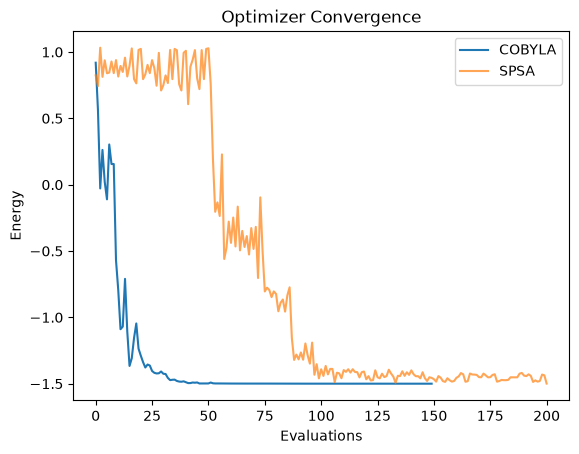

In [5]:
plt.plot(history_cobyla, label="COBYLA")
# SPSA does 2 evaluations per iteration
plt.plot(history_spsa, label="SPSA", alpha=0.7)
plt.xlabel("Evaluations")
plt.ylabel("Energy")
plt.title("Optimizer Convergence")
plt.legend()
plt.show()